In [1]:
#Colab ONLY!
##!pip install torch sounddevice numpy
##!pip install -U transformers

In [1]:
#Colab ONLY!
#from google.colab import output


from transformers import pipeline
from transformers import AutoProcessor, AutoModelForSpeechSeq2Seq, WhisperProcessor, WhisperForConditionalGeneration, pipeline

from IPython.display import Javascript, display

from base64 import b64decode
import io
import numpy as np
import scipy.io.wavfile as wavfile

import librosa
import librosa.display
import matplotlib.pyplot as plt
import soundfile as sf
import subprocess

import torch, gc

C:\Users\veikk\PycharmProjects\NeuronetworkTasks\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Voice recognition in Finnish Language

I will be testing pre-trained Wisper voice recognitions models to compare and see how they perform when analysing spoken finnish language. I am starting by declaring the model settings for later use and then creating the recording function. 

In [3]:
settings = {"language": "finnish", "task": "transcribe"}

On the recording function, due to this being in the Google Colab environment, I will have to use the website's microphone permissions. This is done by using Javascript to ask for permission, recording the audio and then passing it for the rest of the code as a recording.

In [4]:
audio_data = None

def _on_audio(data_b64):
    global audio_data
    audio_data = b64decode(data_b64)
    with open("recording.webm", "wb") as f:
        f.write(audio_data)
    subprocess.run(["ffmpeg", "-y", "-i", "recording.webm", "-ar", "16000", "-ac", "1", "recording.wav"])
    print("Recording saved and converted.")

output.register_callback('notebook.on_audio', _on_audio)

def record_audio(seconds=5):
    display(Javascript(f'''
    (async function() {{
        const stream = await navigator.mediaDevices.getUserMedia({{audio: true}});
        const recorder = new MediaRecorder(stream);
        const chunks = [];

        recorder.ondataavailable = e => chunks.push(e.data);
        recorder.start();

        await new Promise(r => setTimeout(r, {seconds} * 1000));
        recorder.stop();

        await new Promise(r => recorder.onstop = r);
        stream.getTracks().forEach(t => t.stop());

        const blob = new Blob(chunks, {{type: 'audio/webm'}});
        const reader = new FileReader();
        reader.readAsDataURL(blob);
        await new Promise(r => reader.onloadend = r);

        const b64 = reader.result.split(',')[1];
        google.colab.kernel.invokeFunction('notebook.on_audio', [b64], {{}});
    }})();
    '''))
    print(f"Recording for {seconds} seconds... Speak now!")

record_audio(seconds=5)

<IPython.core.display.Javascript object>

Recording for 5 seconds... Speak now!
Recording saved and converted.


### Visualisation

After the recording has completed, it will output .wav recording, so the librosa is able to properly load the audio file. The audio is then loaded as a Waveform and a Mel-Spectorgram.

In the spectogram X-axis showcases the time of the recording, to visualise where certain sounds happen.

Y-axis showcases the sound frequency on the mel scale, hence the name. This filters out sounds that humans are not able to hear.

The colors on the spectogram determine the Decibels or the loudness of the sound at the given moment. The DB is higher with warmer colors, while quiter when showing colder colors.

Audio length: 114600 samples, max amplitude: 0.5075


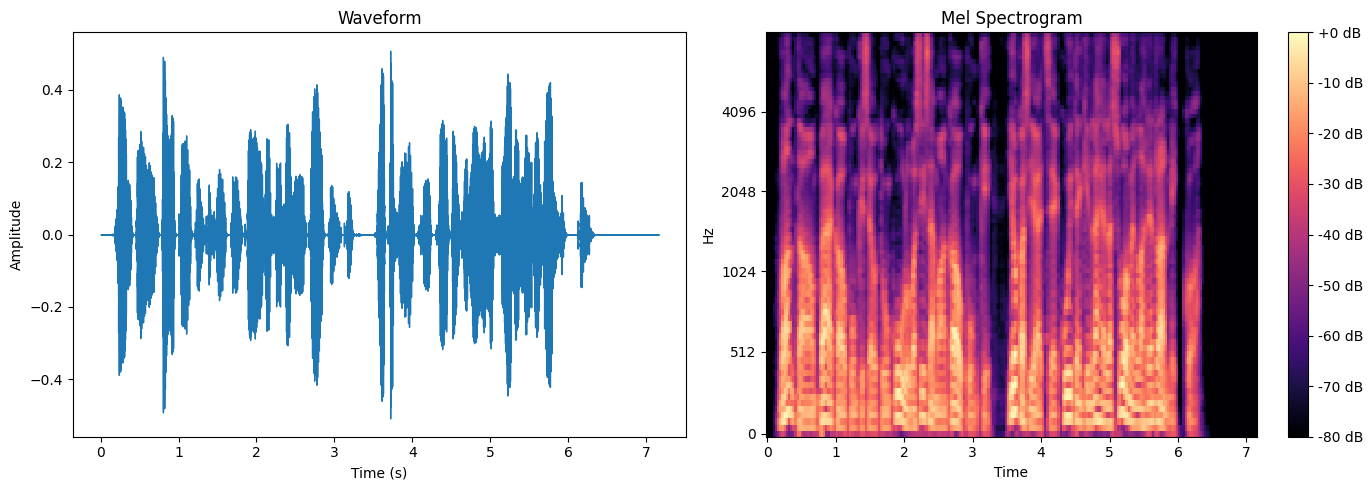

In [2]:
audio, sr = librosa.load("audio_samples/vantaa.wav", sr=16000)
print(f"Audio length: {len(audio)} samples, max amplitude: {np.max(np.abs(audio)):.4f}")

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
librosa.display.waveshow(audio, sr=sr)
plt.title("Waveform")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=80)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
librosa.display.specshow(mel_spec_db, sr=sr, x_axis="time", y_axis="mel")
plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram")

plt.tight_layout()
plt.show()

### Analysis and Comparison

Now that recording has been made and the visualisation showcases that there is something going on. Whisper will now process it with the settings that were determined at the very beginning. Those being transcribe and language being set to finnish.

I will be using 3 pipelines (Large, Tiny and Basic), each using a different sized set of data.

In [6]:
largepipe = pipeline("automatic-speech-recognition", model="openai/whisper-large")

result = largepipe("recording.wav", generate_kwargs=settings)
print("Transcription:", result["text"])

del largepipe
gc.collect()
torch.cuda.empty_cache()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> to see related `.generate()` flags.


Transcription:  Kuuletko minua?


In [7]:
tinypipe = pipeline("automatic-speech-recognition", model="openai/whisper-tiny")

result = tinypipe("recording.wav", generate_kwargs=settings)
print("Transcription:", result["text"])

del tinypipe
gc.collect()
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Transcription:  Olen. Olenkö minä.


In [10]:
basicpipe = pipeline("automatic-speech-recognition", model="openai/whisper-base")

result = basicpipe("recording.wav", generate_kwargs=settings)
print("Transcription:", result["text"])

del basicpipe
gc.collect()
torch.cuda.empty_cache()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

normalizer.json: 0.00B [00:00, ?B/s]

added_tokens.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

preprocessor_config.json: 0.00B [00:00, ?B/s]

Transcription:  No, kura.


From the results, we can see that Large performs pretty much perfectly, recognising what I had said. However when the model gets smaller, the results become less meaningful. Both Tiny and Base completely fail to transcribe what I had said in the recording.

When putting up "an Accent" the large model starts to all fail a bit, however it can still recognise the main punctuation. Like saying "Minä olen Suomalainen" would be transcribed as "Minä olen Suomehlaiden"